# Week 3 — Empirical modeling: fitting

Companion notebook of the third lecture. Last week we **guessed** the yeast constant $k=0.00082$ "by hand"; today we make that step **systematic**: the least-squares criterion, fitting lines and polynomials, transformed fitting, and how to **choose** the model type (underfitting vs overfitting, validation).

**How to run**: Anaconda locally (`jupyter lab`), or Colab/Binder from the [course repository](https://github.com/liwt31/MathModel). Run cells in order with `Shift+Enter`.

**Note.** The exercises here and on the slides are **practice for yourself** — they are **not** the graded assignments. Problem sets are released separately on Blackboard, with due dates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:                                  # optional style file, ships with the course
    plt.style.use("mm.mplstyle")
except OSError:
    pass

## 1. The two questions of model fitting

Given data $(x_i, y_i)$, fitting means choosing a curve that **best** explains them. Two separate questions:

1. **Given a model type, find its parameters** — e.g. we chose $\Delta p_n = k\,p_n$ for the yeast; what is $k$?
2. **Given the data, choose the model type** — why proportional, and not exponential? (Week 2 answered by *refinement*; today we get systematic tools.)

Both need a precise definition of **best**. We compare three criteria, then study the most convenient one: **least squares**.

## 2. The least-squares criterion for a line

Fit $y = ax + b$ to $m$ points by minimizing the sum of squared deviations
$$S(a,b) = \sum_{i=1}^m \big(y_i - (ax_i+b)ig)^2.$$
Setting $\partial S/\partial a = \partial S/\partial b = 0$ gives the **normal equations**
$$a \textstyle\sum x_i^2 + b \sum x_i = \sum x_i y_i, \qquad
a \sum x_i + b\,m = \sum y_i.$$

A two-by-two linear system! Solve it **by hand** on the lecture's data set $x = 1..4$, $y = 8.1, 22.1, 60.1, 165$:

In [2]:
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([8.1, 22.1, 60.1, 165.0])

Sx2, Sx = (x**2).sum(), x.sum()
Sxy, Sy = (x*y).sum(), y.sum()
print(f"sum x^2 = {Sx2},  sum x = {Sx},  sum xy = {Sxy},  sum y = {Sy}")

A = np.array([[Sx2, Sx],
              [Sx,  len(x)]])
rhs = np.array([Sxy, Sy])
a, b = np.linalg.solve(A, rhs)
print(f"normal equations: {Sx2:.0f}a + {Sx:.0f}b = {Sxy},  {Sx:.0f}a + 4b = {Sy}")
print(f"solution: a = {a:.4f},  b = {b:.4f}   (deck: a = 50.87, b = -63.35)")

sum x^2 = 30.0,  sum x = 10.0,  sum xy = 892.6,  sum y = 255.3
normal equations: 30a + 10b = 892.6,  10a + 4b = 255.3
solution: a = 50.8700,  b = -63.3500   (deck: a = 50.87, b = -63.35)


The same answer arrives instantly from the standard tool — `np.polyfit` fits a polynomial of any degree (`deg=1` is the line):

polyfit: a = 50.8700,  b = -63.3500


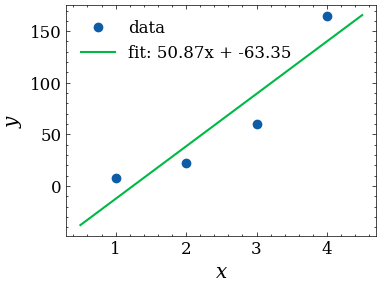

In [3]:
a2, b2 = np.polyfit(x, y, deg=1)
print(f"polyfit: a = {a2:.4f},  b = {b2:.4f}")

xs = np.linspace(0.5, 4.5, 100)
plt.plot(x, y, "o", label="data")
plt.plot(xs, a2 * xs + b2, "-", label=f"fit: {a2:.2f}x + {b2:.2f}")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(frameon=False)
plt.show()

**Prediction** is now one evaluation — at $x = 2.5$ (inside the data range, an interpolation):
$y = 50.87 \times 2.5 - 63.35 = 63.825$.

## 3. Any model linear in its parameters: $y = a\,g(x) + b\,h(x)$

The same recipe works for $f(x) = a\,g(x) + b\,h(x)$ for **any** basis functions $g, h$ — the normal equations just replace $x_i$ by $g(x_i)$, $h(x_i)$.

Lecture example: $f(x) = a\cos(\pi x) + b\sin(\pi x)$ on $x = -1, -\tfrac12, 0, \tfrac12, 1$, $y = -1, 0, 1, 2, 1$:

sums: g^2 = 3, gh = 0, h^2 = 2, gy = 1, hy = 2
a = 0.3333   (deck: 1/3),   b = 1.0000   (deck: 1)


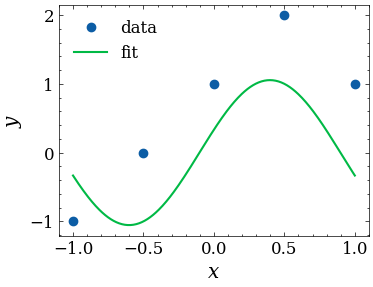

In [4]:
xd = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
yd = np.array([-1.0, 0.0, 1.0, 2.0, 1.0])

g = np.cos(np.pi * xd)
h = np.sin(np.pi * xd)

A = np.array([[ (g*g).sum(), (g*h).sum() ],
              [ (g*h).sum(), (h*h).sum() ]])
rhs = np.array([ (g*yd).sum(), (h*yd).sum() ])
a, b = np.linalg.solve(A, rhs)
print(f"sums: g^2 = {(g*g).sum():.0f}, gh = {(g*h).sum():.0f}, h^2 = {(h*h).sum():.0f}, gy = {(g*yd).sum():.0f}, hy = {(h*yd).sum():.0f}")
print(f"a = {a:.4f}   (deck: 1/3),   b = {b:.4f}   (deck: 1)")

xs = np.linspace(-1, 1, 300)
plt.plot(xd, yd, "o", label="data")
plt.plot(xs, a * np.cos(np.pi * xs) + b * np.sin(np.pi * xs), "-", label="fit")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(frameon=False)
plt.show()

This is why least squares is so convenient: **any** model of the form $\sum_j c_j \phi_j(x)$ (polynomials, trigonometric polynomials, splines, ...) leads to a **linear system**. Engineering uses trigonometric-polynomial approximations (Fourier series) everywhere.

## 4. Transformed least squares: $y = b\,e^{ax}$

$y = b e^{ax}$ depends **nonlinearly** on $a$ — the normal equations no longer solve it. But taking logarithms,
$$\ln y = \ln b + ax,$$
the model becomes **linear** in $a$ and $\tilde b = \ln b$ on the transformed data $(x_i, \ln y_i)$:

a = 1.0043   (deck: 1),   b = 2.9644   (deck: 3.0042)
ln y = [2.09 3.1  4.1  5.11]   <- exactly the deck's data2 table


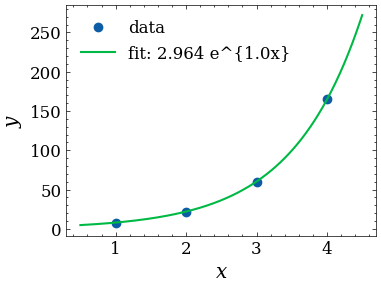

In [5]:
lny = np.log(y)
a3, btilde = np.polyfit(x, lny, deg=1)
b3 = np.exp(btilde)
print(f"a = {a3:.4f}   (deck: 1),   b = {b3:.4f}   (deck: 3.0042)")
print("ln y =", lny.round(2), "  <- exactly the deck's data2 table")

xs = np.linspace(0.5, 4.5, 200)
plt.plot(x, y, "o", label="data")
plt.plot(xs, b3 * np.exp(a3 * xs), "-", label=f"fit: {b3:.3f} e^{{{a3:.1f}x}}")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(frameon=False)
plt.show()

**Small print**: minimizing the squared error of $\ln y$ is **not** the same as minimizing the squared error of $y$ — the transform re-weights large and small $y$ (it cares about *relative* error). Usually that is what you want for exponential data, but say which error you are minimizing.

## 4b. The yeast $k$, systematically

Close last week's loop: fit $\Delta p_n = k\,p_n$ to the early yeast data by least squares. With no intercept, minimizing $\sum (\Delta p_n - k p_n)^2$ gives
$$k = \\frac{\sum p_n\, \\Delta p_n}{\sum p_n^2}.$$

pure proportional: k = 0.4960  (average early growth rate)


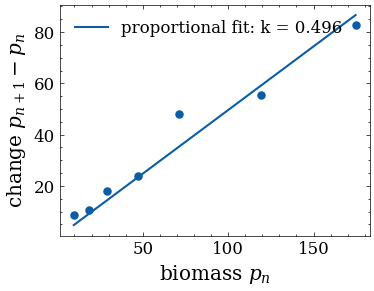

In [6]:
time = np.arange(19)
observed = np.array([9.6, 18.3, 29.0, 47.2, 71.1, 119.1, 174.6, 257.3,
                     350.7, 441.0, 513.3, 559.7, 594.8, 629.4, 640.8,
                     651.1, 655.9, 659.6, 661.8])
init = observed[:8]
change = init[1:] - init[:-1]
p_early = init[:-1]

k1 = (p_early * change).sum() / (p_early**2).sum()
print(f"pure proportional: k = {k1:.4f}  (average early growth rate)")

plt.scatter(p_early, change, s=26)
plt.plot(p_early, k1 * p_early, "-", lw=1.5, label=f"proportional fit: k = {k1:.3f}")
plt.xlabel(r"biomass $p_n$"); plt.ylabel(r"change $p_{n+1}-p_n$")
plt.legend(frameon=False); plt.show()

The pure-proportional fit averages the early fast growth with the later slowdown — it fits neither well. **Refine**, exactly as in Week 2: the change should also be proportional to the room left, $\Delta p_n = k\,(665-p_n)\,p_n$. With $x_n = (665-p_n)\,p_n$, least squares gives $k = \sum x_n\Delta p_n / \sum x_n^2$:

refined k = 0.00095   (week 2 simulated with 0.00082)


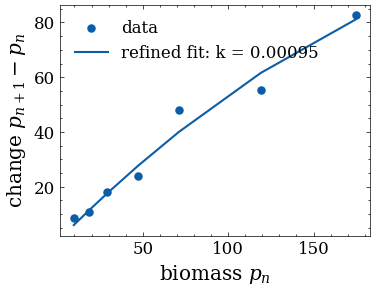

In [7]:
x = (665 - p_early) * p_early
k2 = (x * change).sum() / (x**2).sum()
print(f"refined k = {k2:.5f}   (week 2 simulated with 0.00082)")

plt.scatter(p_early, change, s=26, label="data")
plt.plot(p_early, k2 * x, "-", lw=1.5, label=f"refined fit: k = {k2:.5f}")
plt.xlabel(r"biomass $p_n$"); plt.ylabel(r"change $p_{n+1}-p_n$")
plt.legend(frameon=False); plt.show()

$k \approx 0.001$ — close to the textbook's $0.00082$ (fitted differently, on all 19 hours). The lesson: least squares turns *guess the constant* into a **defined, repeatable computation**.

## 5. Fitting polynomials: the tape recorder

A tape counter $c$ and the elapsed playing time $t$ — obviously related, but how? Try polynomials of increasing degree:

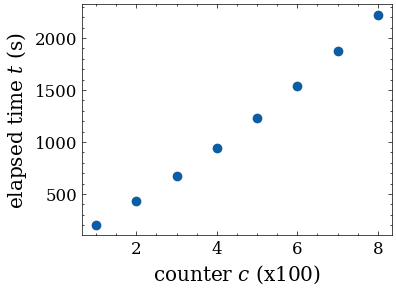

In [8]:
c = np.arange(1, 9)                    # counter, in units of 100
t = np.array([205, 430, 677, 945, 1233, 1542, 1872, 2224])

plt.plot(c, t, "o")
plt.xlabel("counter $c$ (x100)"); plt.ylabel("elapsed time $t$ (s)")
plt.show()

degree 1:  max |residual| =    73.58
degree 3:  max |residual| =     0.53
degree 7:  max |residual| =     0.00


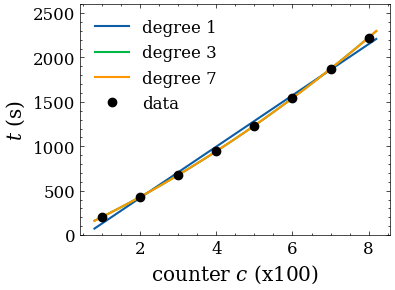

In [9]:
cs = np.linspace(0.8, 8.2, 300)
for deg in [1, 3, 7]:
    coeffs = np.polyfit(c, t, deg=deg)
    resid = t - np.polyval(coeffs, c)
    print(f"degree {deg}:  max |residual| = {np.abs(resid).max():8.2f}")
    plt.plot(cs, np.polyval(coeffs, cs), "-", label=f"degree {deg}")
plt.plot(c, t, "o", color="black", label="data")
plt.ylim(0, 2600); plt.xlabel("counter $c$ (x100)"); plt.ylabel("$t$ (s)")
plt.legend(frameon=False); plt.show()

Degree 7 passes through **all** points (max residual $\approx 0$) — that is **interpolation**, not fitting. Between the data points it **wiggles** with no physical reason: a polynomial of degree 7 has 8 free parameters for 8 points, so it has no choice. This is **overfitting**: fitting the noise, losing the trend.

## 6. Choosing the model type: underfit vs overfit

The second big question of fitting. A clean experiment: seven data points (generated from a rapidly growing process), fit polynomials of different degrees, and judge on a **validation set** the model has never seen:

/tmp/ipykernel_3110082/1463488307.py:12: RankWarning: Polyfit may be poorly conditioned
  cf = np.polyfit(xtr, ytr, deg=d)
/tmp/ipykernel_3110082/1463488307.py:18: RankWarning: Polyfit may be poorly conditioned
  cf = np.polyfit(xtr, ytr, deg=d)


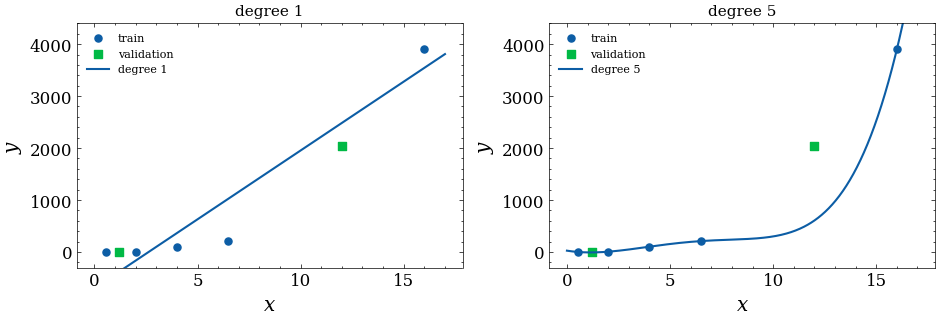

In [10]:
x = np.array([0.55, 1.2, 2.0, 4.0, 6.5, 12.0, 16.0])
y = np.array([0.13, 0.64, 5.8, 102.0, 210.0, 2030.0, 3900.0])

train = np.array([True, False, True, True, True, False, True])   # 5 train, 2 validation
xtr, ytr = x[train], y[train]
xva, yva = x[~train], y[~train]

orders = [1, 2, 3, 4, 5]
err_tr, err_va = [], []
xs = np.linspace(0, 17, 400)
for d in orders:
    cf = np.polyfit(xtr, ytr, deg=d)
    err_tr.append(np.sqrt(np.mean((np.polyval(cf, xtr) - ytr)**2)))
    err_va.append(np.sqrt(np.mean((np.polyval(cf, xva) - yva)**2)))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
for ax, d in zip(axes, [1, 5]):
    cf = np.polyfit(xtr, ytr, deg=d)
    ax.scatter(xtr, ytr, s=26, label="train")
    ax.scatter(xva, yva, s=26, marker="s", label="validation")
    ax.plot(xs, np.polyval(cf, xs), "-", lw=1.5, label=f"degree {d}")
    ax.set_ylim(-300, 4400); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    ax.set_title(f"degree {d}", fontsize=11); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

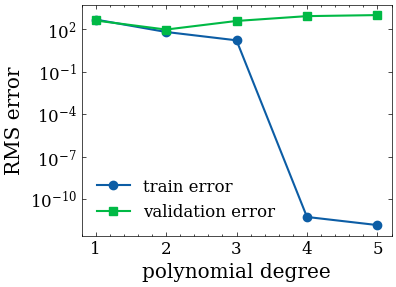

degree 1:  train   488.77   validation     417.61
degree 2:  train    64.63   validation      95.60
degree 3:  train    16.63   validation     387.75
degree 4:  train     0.00   validation     849.24
degree 5:  train     0.00   validation    1007.22


In [11]:
plt.plot(orders, err_tr, "o-", label="train error")
plt.plot(orders, err_va, "s-", label="validation error")
plt.xlabel("polynomial degree"); plt.ylabel("RMS error")
plt.yscale("log"); plt.legend(frameon=False)
plt.show()

for d, e1, e2 in zip(orders, err_tr, err_va):
    print(f"degree {d}:  train {e1:8.2f}   validation {e2:10.2f}")

**Underfitting** (degree too low): both errors large — the model cannot even express the trend. **Overfitting** (degree too high): train error keeps dropping, **validation error explodes** — the model memorized the training points. The sweet spot is where validation error is minimal; that is the principled answer to "which model type?", and it is exactly the idea machine learning scales up (Week 9).

## 6b. Measuring fit quality: RMSE and $R^2$

Two standard numbers summarize a fit. **RMSE** (root-mean-square error) is the typical residual size in the units of $y$; **$R^2$** is the fraction of the data's variance the model explains ($1$ = perfect, $0$ = no better than predicting the mean):
$$\mathrm{RMSE} = \sqrt{\tfrac{1}{m}\textstyle\sum_i (y_i - f(x_i))^2}, \qquad
R^2 = 1 - \frac{\sum_i (y_i - f(x_i))^2}{\sum_i (y_i - \bar y)^2}.$$

In [12]:
for deg in [1, 3, 7]:
    cf = np.polyfit(c, t, deg=deg)
    r = t - np.polyval(cf, c)
    rmse = np.sqrt((r**2).mean())
    r2 = 1 - (r**2).sum() / ((t - t.mean())**2).sum()
    print(f"degree {deg}:  RMSE = {rmse:6.1f} s,  R^2 = {r2:.4f}")

degree 1:  RMSE =   48.0 s,  R^2 = 0.9948
degree 3:  RMSE =    0.3 s,  R^2 = 1.0000
degree 7:  RMSE =    0.0 s,  R^2 = 1.0000


The degree-7 polynomial has RMSE $\approx 0$ and $R^2 = 1$ — **perfect on the data it was fitted to**, and still a gamble between the points. Never report $R^2$ without saying whether it was computed on fitted or held-out data.

## 6c. One-term models: the Tukey ladder

How do you **choose** a transform systematically? Try functions from the **Tukey ladder of powers** for $x$ and $y$ ($x^2, x, \sqrt{x}, \ln x, 1/\sqrt x, 1/x, \dots$), plot $g(y)$ against $f(x)$, and keep the pair that looks **linear**. The lecture's examples: bluefish population (years vs biomass) and rod temperature (position vs temperature).

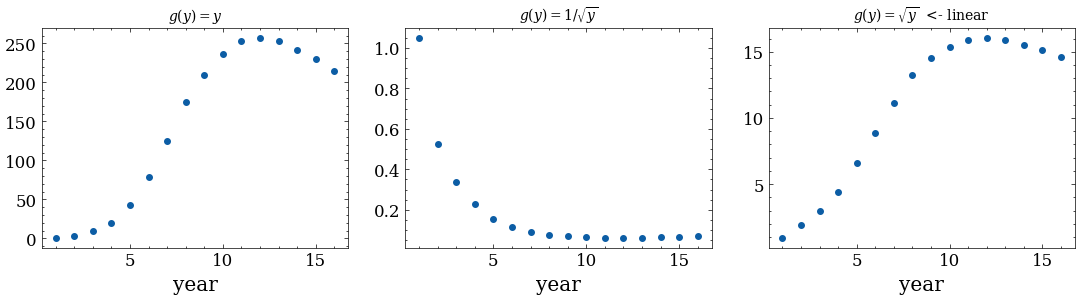

In [13]:
yb = np.array([0.91, 3.6, 8.9, 19.4, 43.0, 79.1, 124.4, 174.6, 210.1, 236.3, 253.2, 256.8, 252.9, 241.7, 229.6, 214.2])
xb = np.arange(1, 17)                 # years 1984-1999, biomass in 10^4 lb

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].plot(xb, yb, "o", ms=4); axes[0].set_title(r"$g(y)=y$", fontsize=10)
axes[1].plot(xb, 1/np.sqrt(yb), "o", ms=4); axes[1].set_title(r"$g(y)=1/\sqrt{y}$", fontsize=10)
axes[2].plot(xb, np.sqrt(yb), "o", ms=4); axes[2].set_title(r"$g(y)=\sqrt{y}$  <- linear", fontsize=10)
for ax in axes: ax.set_xlabel("year")
fig.tight_layout(); plt.show()

sqrt(y) = 1.080 x + 1.637   (deck: 1.21 x + 1.09)


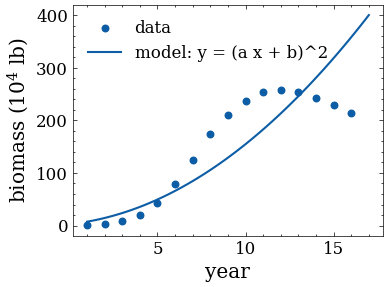

In [14]:
a, b = np.polyfit(xb, np.sqrt(yb), deg=1)
print(f"sqrt(y) = {a:.3f} x + {b:.3f}   (deck: 1.21 x + 1.09)")
xs = np.linspace(1, 17, 100)
plt.scatter(xb, yb, s=22, label="data")
plt.plot(xs, (a * xs + b)**2, "-", label="model: y = (a x + b)^2")
plt.xlabel("year"); plt.ylabel(r"biomass ($10^4$ lb)"); plt.legend(frameon=False)
plt.show()

The ladder turns **model choice** into a small, systematic search. (The lecture also fits the rod-temperature data with $\ln y = a\ln x + b$: a power law $y = e^{-6.798} x^{1.5}$.)

## 7. Interpolation as a tool

Sometimes the data are **accurate** (no noise to average away) and you genuinely need values **between** points — then interpolate: the curve goes **through every point** by construction. `scipy.interpolate` provides the standard tools:

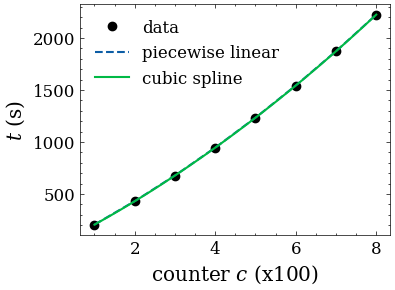

In [15]:
from scipy.interpolate import CubicSpline, interp1d

cs = np.linspace(1, 8, 400)
lin = interp1d(c, t)                 # piecewise linear
spl = CubicSpline(c, t)              # cubic spline: smooth, through all points

plt.plot(c, t, "o", color="black", label="data")
plt.plot(cs, lin(cs), "--", label="piecewise linear")
plt.plot(cs, spl(cs), "-", label="cubic spline")
plt.xlabel("counter $c$ (x100)"); plt.ylabel("$t$ (s)")
plt.legend(frameon=False); plt.show()

**Rule of thumb**: noisy data $\Rightarrow$ fit (smooths); exact data, values between points $\Rightarrow$ interpolate (preserves). No spline theory this week — just know the tool exists and what it promises.

## 7b. Divided differences: choosing the polynomial order

The classic tool for the **order** question: a **divided difference table**. First divided differences approximate the derivative, second divided differences the second derivative — and if the third differences are (nearly) zero, a **quadratic** already captures the trend.

In [16]:
def divdiff(x, y):
    n = len(y)
    col = np.array(y, dtype=float)
    table = [col.copy()]
    for level in range(n - 1):
        col = (col[1:] - col[:-1]) / (x[level + 1:] - x[:n - 1 - level])
        table.append(col.copy())
    return table

for row in divdiff(c, t):
    print(np.round(row, 4))

[ 205.  430.  677.  945. 1233. 1542. 1872. 2224.]
[225. 247. 268. 288. 309. 330. 352.]
[11.  10.5 10.  10.5 10.5 11. ]
[-0.1667 -0.1667  0.1667  0.      0.1667]
[ 0.      0.0833 -0.0417  0.0417]
[ 0.0167 -0.025   0.0167]
[-0.0069  0.0069]
[0.002]


The third differences of the tape-recorder table are tiny ($\approx 0.001$) — so a **quadratic** is the right order, not the 7th-order interpolator. Refit by least squares (Week 3's own criterion) and compare:

quadratic coefficients: [1.04640e+01 1.94226e+02 1.43000e-01]   (deck: a=10.464, b=194.226, c=0.142)


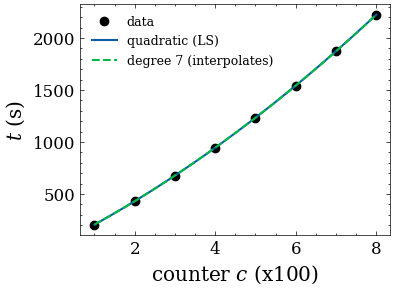

In [17]:
cf2 = np.polyfit(c, t, deg=2)
print("quadratic coefficients:", np.round(cf2, 3), "  (deck: a=10.464, b=194.226, c=0.142)")

cs = np.linspace(1, 8, 300)
plt.plot(c, t, "o", color="black", label="data")
plt.plot(cs, np.polyval(cf2, cs), "-", label="quadratic (LS)")
plt.plot(cs, np.polyval(np.polyfit(c, t, 7), cs), "--", label="degree 7 (interpolates)")
plt.xlabel("counter $c$ (x100)"); plt.ylabel("$t$ (s)"); plt.legend(frameon=False, fontsize=9)
plt.show()

## 8. Case study: the Wordle curve (2023 MCM Problem C)

The **2023 MCM Problem C** handed teams $359$ days of real data from the New York Times word game **Wordle**: for each day, how many players **reported a result** (the game's Share button posts the colored-tile pattern, and the Times counts the posts). The first task: **forecast the number of reported results on March 1, 2023**. The series rises fast to a January 2022 peak above $300\,000$ and then decays with a visible weekly ripple.

The Outstanding paper of team **2301192** fit it with **Prophet**, an open-source forecasting library released by Facebook in 2018. Prophet's idea is exactly Section 3's: a model that is **linear in its parameters** turns fitting into one least-squares problem. The model multiplies a slow trend $g(t)$, a weekly cycle $s(t)$, and holiday bumps $h(t)$; on **logarithmic** data a product becomes a sum, $\ln y = \ln g + \ln s + \ln h$, and each piece is a fixed set of columns:

- **trend**: piecewise linear, free to change slope at **changepoints** (hinge columns $(t-c_j)^+$; Prophet uses $60$ candidates and an $L^1$ penalty that shrinks unneeded ones);
- **weekly cycle**: a Fourier sum with period $P = 7$ (sine and cosine columns);
- **holidays**: one indicator column per holiday window (the paper uses Valentine's, Easter, Halloween, Thanksgiving, Christmas).

The library fits everything at once with the Stan optimizer. We rebuild the same recipe by hand below — the paper's model and ours differ only in the number of columns.

In [18]:
import pandas as pd

URL = "https://raw.githubusercontent.com/liwt31/MathModel/refs/heads/2026/data/Problem_C_Data_Wordle.xlsx"
df = pd.read_excel(URL)
df.columns = [c.replace("  ", " ").strip() for c in df.columns]   # the file has a stray double space
print(df.shape, "days from", df.Date.min().date(), "to", df.Date.max().date())
df.head(3)

(359, 12) days from 2022-01-07 to 2022-12-31


,Date,Contest number,Word,Number of reported results,Number in hard mode,1 try,2 tries,3 tries,4 tries,5 tries,6 tries,7 or more tries (X)
0,2022-01-07,202,slump,80630,1362,1,3,23,39,24,9,1
1,2022-01-08,203,crank,101503,1763,1,5,23,31,24,14,2
2,2022-01-09,204,gorge,91477,1913,1,3,13,27,30,22,4


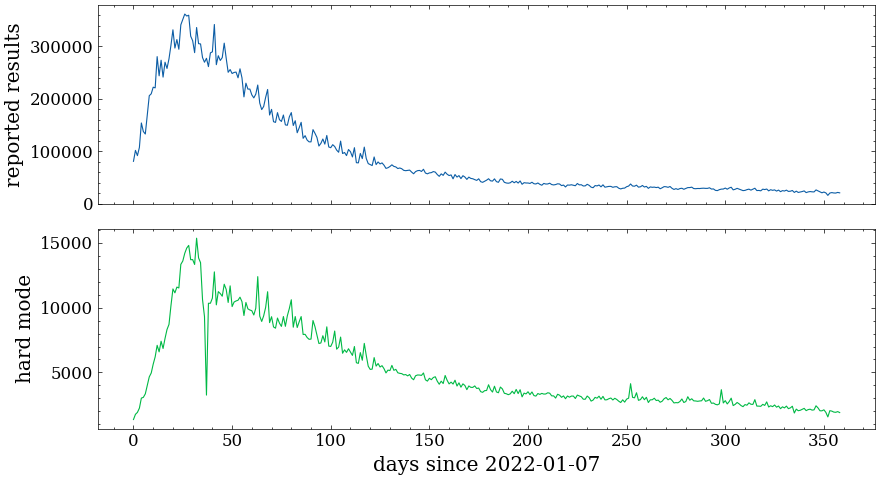

In [19]:
day = (df["Date"] - df["Date"].min()).dt.days.values             # t = days since the first record
rep = df["Number of reported results"].values.astype(float)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(day, rep, lw=0.8)
axes[0].set_ylabel("reported results")
axes[1].plot(day, df["Number in hard mode"].values, lw=0.8, color="C1")
axes[1].set_ylabel("hard mode"); axes[1].set_xlabel("days since 2022-01-07")
fig.tight_layout(); plt.show()

The paper's Figure 4 is exactly these two panels. Now take **logarithms** of the reported counts (variance stabilization, and the product $g \cdot s \cdot h$ becomes the sum $\ln g + \ln s + \ln h$), and assemble the **design matrix**: a constant and $t$ for the first line segment, one hinge $(t - c_j)^+$ per candidate changepoint, sine/cosine pairs for the week, and one indicator per holiday window.

In [20]:
from numpy import sin, cos

HOLIDAYS = pd.to_datetime(["2022-02-14", "2022-04-24", "2022-10-31",
                           "2022-11-24", "2022-12-25"])          # the paper's five holidays
hol_idx = [np.flatnonzero(df["Date"].isin([h, h - pd.Timedelta(days=1), h + pd.Timedelta(days=1)]).values)
           for h in HOLIDAYS]

n = len(day)
train_end = 319                                                  # train: through 2022-11-21, like the paper
cps = np.linspace(5, train_end * 0.9, 24)                        # 24 candidate changepoints, inside the training window
cols = [np.ones(n), day.astype(float)]                           # first line segment
cols += [np.maximum(day - cj, 0.0) for cj in cps]                # hinges at the changepoints
cols += [f(2 * np.pi * nn * day / 7.0) for nn in range(1, 4) for f in (sin, cos)]
for idx in hol_idx:                                              # one indicator per holiday window
    col = np.zeros(n); col[idx] = 1.0
    cols.append(col)
X = np.column_stack(cols)

X_tr, X_te = X[:train_end], X[train_end:]
lny_tr, lny_te = np.log(rep[:train_end]), np.log(rep[train_end:])
print("design matrix:", X.shape, "->", X.shape[1], "coefficients for", train_end, "training days")

beta, *_ = np.linalg.lstsq(X_tr, lny_tr, rcond=None)

design matrix: (359, 37) -> 37 coefficients for 319 training days


**Validation**, the paper's discipline: train through 2022-11-21, test on the $40$ held-out days. The paper reports (its Table 4, on the count scale) $R^2 = 0.9924$, RMSE $= 7768$, MAPE $= 4.8\,\%$ — those numbers are computed **on the fitted training window**, where the January peak makes the total variance huge and $R^2$ easy to win. We print both views: on the training window our mini-Prophet matches the paper, on the held-out tail the linear-in-log trend overshoots the slowing decay, which is exactly the kind of honesty a test set is for:

train : R^2 = 0.9875,  RMSE =   10190,  MAPE = 4.90 %    (paper's Table 4: R^2 = 0.9924, RMSE = 7768, MAPE = 4.80 %)
test  : R^2 = 0.3907,  RMSE =    1920,  MAPE = 7.16 %


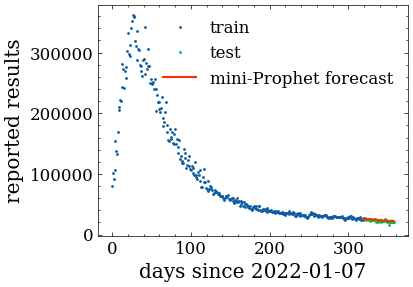

In [21]:
def metrics(y, p):
    r2 = 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return f"R^2 = {r2:.4f},  RMSE = {np.sqrt(((y - p) ** 2).mean()):7.0f},  MAPE = {(np.abs(y - p) / y).mean() * 100:.2f} %"

pred_tr, pred_te = np.exp(X_tr @ beta), np.exp(X_te @ beta)
y_tr, y_te = rep[:train_end], rep[train_end:]
print("train :", metrics(y_tr, pred_tr), "   (paper's Table 4: R^2 = 0.9924, RMSE = 7768, MAPE = 4.80 %)")
print("test  :", metrics(y_te, pred_te))

plt.plot(day[:train_end], y_tr, ".", ms=2, label="train")
plt.plot(day[train_end:], y_te, ".", ms=2, label="test")
plt.plot(day[train_end:], pred_te, "-", color="C3", label="mini-Prophet forecast")
plt.xlabel("days since 2022-01-07"); plt.ylabel("reported results"); plt.legend(frameon=False)
plt.show()

**The forecast.** The design matrix extends mechanically to any future date: hinges and sines continue, holiday indicators switch on. The paper's answer for March 1, 2023 is $14534$ with a 95\,\% band $(13175, 16128)$; the band comes from Prophet simulating possible future trend paths, which our point forecast skips. Our point forecast lands above the paper's: with a piecewise-linear trend, the March forecast is decided almost entirely by the slope of the **last segment**, and Prophet's $L^1$ shrinkage plus its re-tuned $\tau$ (the paper lowers it for the final answer) bend that slope down. Same recipe, different tuning — the same sensitivity the second team's fit will show on the slides.

forecast for 2023-03-01: 17,818 reported results   (paper: 14534, band 13175-16128)


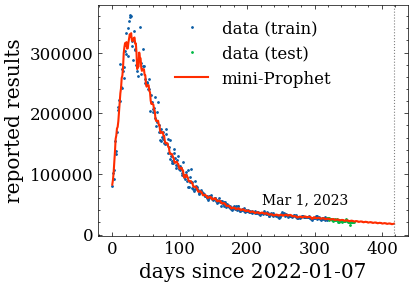

In [22]:
t_fut = np.arange(n, (pd.Timestamp("2023-03-01") - df["Date"].min()).days + 1)
cols_f = [np.ones(len(t_fut)), t_fut.astype(float)]
cols_f += [np.maximum(t_fut - cj, 0.0) for cj in cps]
cols_f += [f(2 * np.pi * nn * t_fut / 7.0) for nn in range(1, 4) for f in (sin, cos)]
cols_f += [np.zeros(len(t_fut)) for _ in hol_idx]                # no holidays after Dec 25 in range
forecast = np.exp(np.column_stack(cols_f) @ beta)

print(f"forecast for 2023-03-01: {forecast[-1]:,.0f} reported results   (paper: 14534, band 13175-16128)")

plt.plot(day[:train_end], rep[:train_end], ".", ms=2, label="data (train)")
plt.plot(day[train_end:], y_te, ".", ms=2, label="data (test)")
plt.plot(np.concatenate([day, t_fut]), np.concatenate([np.exp(X @ beta), forecast]), "-", color="C3", label="mini-Prophet")
plt.axvline(t_fut[-1], color="gray", lw=0.8, ls=":")
plt.annotate("Mar 1, 2023", (t_fut[-1], forecast[-1]), xytext=(-95, 14), textcoords="offset points")
plt.xlabel("days since 2022-01-07"); plt.ylabel("reported results"); plt.legend(frameon=False)
plt.show()

The paper's Figure 6 separates the fitted pieces (trend, holidays, weekly cycle). We can do the same with our coefficient vector: the trend panel shows the piecewise-linear part alone, the weekly panel the Fourier part alone (as a multiplicative boost above $1$), and the holiday panel the five holiday windows (as percent changes). **One series, several curves multiplied together.** Thanksgiving and Christmas fall *after* the training cutoff, so the training data cannot identify their coefficients — the two zero bars are the train/test discipline made visible.

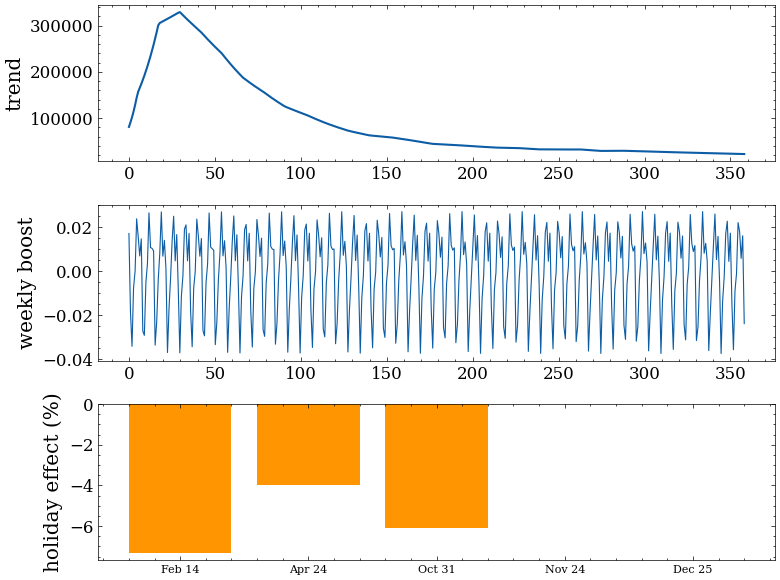

In [23]:
dayg = np.linspace(0, day.max(), 400)
n_trend = 2 + len(cps)                                           # columns: intercept, t, hinges
trend = np.exp(np.column_stack([np.ones_like(dayg), dayg] + [np.maximum(dayg - cj, 0.0) for cj in cps]) @ beta[:n_trend])
weekly = np.exp(np.column_stack([f(2 * np.pi * nn * dayg / 7.0) for nn in range(1, 4) for f in (sin, cos)]) @ beta[n_trend:n_trend + 6])

fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].plot(dayg, trend); axes[0].set_ylabel("trend")
axes[1].plot(dayg, weekly - 1, lw=0.8); axes[1].set_ylabel("weekly boost")
axes[2].bar(range(5), (np.exp(beta[n_trend + 6:]) - 1) * 100, color="C2")
axes[2].set_xticks(range(5), [h.strftime("%b %d") for h in HOLIDAYS], fontsize=8)
axes[2].set_ylabel("holiday effect (%)")
fig.tight_layout(); plt.show()

## Practice exercises

**These are practice for yourself — they are not the graded assignments.** Problem sets are released separately on Blackboard, with due dates.

1. **By hand, then by tool.** Fit $y = ax + b$ to $x = 0, 1, 2, 3$, $y = 1.9, 2.9, 3.6, 4.6$ using the normal equations on paper; check with `np.polyfit`. Predict $y$ at $x = 1.5$.
2. **Transformed fit.** Fit $y = b e^{ax}$ to the same data. Compare the fitted curve against the line fit from Exercise 1 — which has smaller squared error? Which do you believe, and why?
3. **Degree choice.** For the tape-recorder data, plot train and validation error against degree (hold out every third point). Which degree wins, and does the physical argument ($t$ proportional to $c$?) agree?
4. **Chebyshev check.** For the lecture's line fit ($a = 50.87$, $b = -63.35$): compute $D = \sqrt{\frac{1}{m}\sum d_i^2}$ and $d_{\max}$ from the residuals. How close are they? (Recall $D \le c_{\max} \le d_{\max}$; Chebyshev's optimum is between.)
5. **Spline vs polynomial.** Interpolate the tape-recorder data with `CubicSpline` vs `np.polyfit(deg=7)`. Which behaves more sensibly between points?
6. **Wordle forecast.** Decay series like the 2023 C reported-results curve can be forecast by transformed least squares: generate $y = 100\,e^{-0.3x} + $ noise, fit $y = b\,e^{ax}$ on the first 12 points, forecast the rest, and report the RMSE on the held-out points.